In [ ]:
# 폰트 설치
# 새 노트북 열 때마다 셀을 실행하고 세션 다시 시작

!apt-get install -y fonts-nanum > /dev/null

In [ ]:
!pip install lightgbm -q

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

from xgboost import XGBRegressor

DATA_DIR = '/content/drive/MyDrive/power_forecast/'

train_df = pd.read_csv(DATA_DIR + 'train_fe.csv')

print('로드 완료')
print('train shape:', train_df.shape)

Mounted at /content/drive
로드 완료
train shape: (204000, 35)


In [ ]:
result_path = DATA_DIR + 'experiment_results.csv'

# 기존 실험 결과 CSV에서 불러오기
existing_results = pd.read_csv(result_path)

print('=== 기존 실험 결과 ===')
print(existing_results.to_string(index=False))

# 실험 3 SMAPE 불러오기 (실험 4 개선폭 계산에 사용)
score_exp3 = existing_results[existing_results['실험번호'] == 3]['SMAPE'].values[0]
print(f'\n실험 3 SMAPE: {score_exp3}')

=== 기존 실험 결과 ===
 실험번호                 실험명   SMAPE     개선폭                                     비고
    0 대회_Baseline_XGBoost 24.0140  0.0000 대회 제공 Baseline, Feature Engineering 없음
    1          FE_XGBoost  8.4242 15.5898              Feature Engineering 추가 효과
    2         LightGBM_전체  9.3881 -0.9639                        XGBoost보다 성능 낮음
    3         유형별_XGBoost  7.2579  2.1302                        유형별 모델 분리 효과 확인

실험 3 SMAPE: 7.2579


In [ ]:
TRAIN_FEATURES = [
    '건물번호', 'building_type_enc',
    '연면적(m2)', '냉방면적(m2)', '태양광용량(kW)', 'ESS저장용량(kWh)', 'PCS용량(kW)',
    'has_solar', 'has_ess', 'is_IDC',
    'month', 'day', 'hour', 'weekday', 'is_weekend',
    'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos',
    '기온(°C)', '강수량(mm)', '풍속(m/s)', '습도(%)', 'THI', 'CDH',
    'building_hour_mean', 'building_weekday_mean', 'building_mean',
    '일조(hr)', '일사(MJ/m2)',
]
TARGET = '전력소비량(kWh)'

def smape(true, pred):
    true, pred = np.array(true), np.array(pred)
    return np.mean(2 * np.abs(true - pred) / (np.abs(true) + np.abs(pred))) * 100

# 날짜 기준 분리
train_mask_all = train_df['일시'] < '20240818 00'
val_mask_all   = train_df['일시'] >= '20240818 00'

tx_all = train_df[TRAIN_FEATURES][train_mask_all]
ty_all = train_df[TARGET][train_mask_all]
vx_all = train_df[TRAIN_FEATURES][val_mask_all]
vy_all = train_df[TARGET][val_mask_all]

print(f'학습 데이터: {len(tx_all):,}행')
print(f'검증 데이터: {len(vx_all):,}행')

학습 데이터: 187,200행
검증 데이터: 16,800행


In [ ]:
param_grid = [
    {
        'max_depth': 4,
        'min_child_weight': 5,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
    },
    {
        'max_depth': 6,
        'min_child_weight': 3,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
    },
    {
        'max_depth': 8,
        'min_child_weight': 1,
        'subsample': 0.9,
        'colsample_bytree': 0.9,
    },
]

best_score  = float('inf')
best_params = None

for i, params in enumerate(param_grid):
    model = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        n_jobs=-1,
        random_state=42,
        early_stopping_rounds=50,
        eval_metric='mae',
        **params
    )
    model.fit(
        tx_all, ty_all,
        eval_set=[(vx_all, vy_all)],
        verbose=False
    )

    pred  = model.predict(vx_all)
    score = smape(vy_all, pred)

    print(f'조합 {i+1}: max_depth={params["max_depth"]}, '
          f'min_child_weight={params["min_child_weight"]}, '
          f'subsample={params["subsample"]}')
    print(f'  SMAPE: {score:.4f}')
    print()

    if score < best_score:
        best_score  = score
        best_params = params

print(f'최적 파라미터: {best_params}')
print(f'최적 SMAPE  : {best_score:.4f}')

조합 1: max_depth=4, min_child_weight=5, subsample=0.8
  SMAPE: 10.0283

조합 2: max_depth=6, min_child_weight=3, subsample=0.8
  SMAPE: 8.3942

조합 3: max_depth=8, min_child_weight=1, subsample=0.9
  SMAPE: 7.5114

최적 파라미터: {'max_depth': 8, 'min_child_weight': 1, 'subsample': 0.9, 'colsample_bytree': 0.9}
최적 SMAPE  : 7.5114


In [ ]:
preds_exp4 = np.zeros(len(train_df))

for btype in train_df['건물유형'].unique():
    train_mask = (train_df['일시'] < '20240818 00') & (train_df['건물유형'] == btype)
    val_mask   = (train_df['일시'] >= '20240818 00') & (train_df['건물유형'] == btype)

    tx = train_df[TRAIN_FEATURES][train_mask]
    ty = train_df[TARGET][train_mask]
    vx = train_df[TRAIN_FEATURES][val_mask]
    vy = train_df[TARGET][val_mask]

    if len(tx) == 0 or len(vx) == 0:
        print(f'  {btype} → 데이터 없음, 건너뜀')
        continue

    model = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        n_jobs=-1,
        random_state=42,
        early_stopping_rounds=50,
        eval_metric='mae',
        **best_params
    )
    model.fit(
        tx, ty,
        eval_set=[(vx, vy)],
        verbose=False
    )

    preds_exp4[val_mask.values] = model.predict(vx)
    print(f'  {btype} 학습 완료')

score_exp4 = smape(
    train_df[TARGET][val_mask_all],
    preds_exp4[val_mask_all.values]
)

print(f'\n실험 4 Validation SMAPE: {score_exp4:.4f}')
print(f'실험 3 대비 개선: {score_exp3 - score_exp4:.4f}')

  호텔 학습 완료
  상용 학습 완료
  병원 학습 완료
  학교 학습 완료
  건물기타 학습 완료
  아파트 학습 완료
  연구소 학습 완료
  백화점 학습 완료
  IDC(전화국) 학습 완료
  공공 학습 완료

실험 4 Validation SMAPE: 6.8899
실험 3 대비 개선: 0.3680


실험 4 결과 저장 완료

실험 결과 비교
실험명                                 SMAPE      개선폭
----------------------------------------------------
대회_Baseline_XGBoost               24.0140  +0.0000
FE_XGBoost                         8.4242 +15.5898
LightGBM_전체                        9.3881  -0.9639
유형별_XGBoost                        7.2579  +2.1302
유형별_XGBoost_튜닝                     6.8899  +0.3680


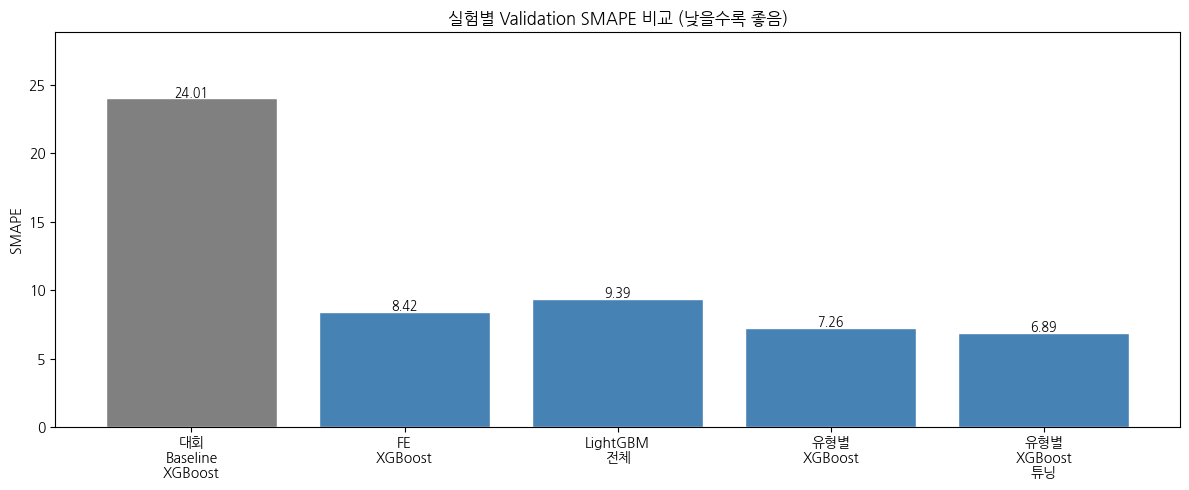

In [ ]:
# 실험 4 결과 CSV에 추가
new_result = pd.DataFrame([{
    '실험번호': 4,
    '실험명': '유형별_XGBoost_튜닝',
    'SMAPE': score_exp4,
    '개선폭': score_exp3 - score_exp4,
    '비고': f'최적파라미터: {best_params}'
}])

combined = pd.concat([existing_results, new_result], ignore_index=True)
combined = combined.drop_duplicates(subset='실험번호', keep='last')
combined = combined.sort_values('실험번호').reset_index(drop=True)
combined.to_csv(result_path, index=False)

print('실험 4 결과 저장 완료')
print()

# 비교표 출력
print('=' * 52)
print('실험 결과 비교')
print('=' * 52)
print(f'{"실험명":<32} {"SMAPE":>8} {"개선폭":>8}')
print('-' * 52)
for _, row in combined.iterrows():
    print(f'{row["실험명"]:<32} {row["SMAPE"]:>8.4f} {row["개선폭"]:>+8.4f}')
print('=' * 52)

# 시각화
plt.figure(figsize=(12, 5))
labels = [name.replace('_', '\n') for name in combined['실험명']]
scores = combined['SMAPE'].tolist()
colors = ['gray'] + ['steelblue'] * (len(combined) - 1)

bars = plt.bar(labels, scores, color=colors, edgecolor='white')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{score:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.title('실험별 Validation SMAPE 비교 (낮을수록 좋음)')
plt.ylabel('SMAPE')
plt.ylim(0, max(scores) * 1.2)
plt.tight_layout()
plt.show()